# DNN DDoS Detection

## 0. Importing Libraries

In [401]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
# import kagglehub

## 1. Data Preprocessing

In [402]:
# path = kagglehub.dataset_download("muhammadumarjavaid/insdn-dataset-2020")

df = pd.read_csv(Path().cwd() / 'data' / 'Dataset.csv')
df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,target
0,185.127.17.56-192.168.20.133-443-53648-6,185.127.17.56,443,192.168.20.133,53648,6,5/2/2020 13:58,245230,44,40,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,185.127.17.56-192.168.20.133-443-53650-6,192.168.20.133,53650,185.127.17.56,443,6,5/2/2020 13:58,1605449,107,149,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.133,35108,192.168.20.2,53,6,5/2/2020 13:58,53078,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.2,53,192.168.20.133,35108,6,5/2/2020 13:58,6975,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,154.59.122.74-192.168.20.133-443-60900-6,192.168.20.133,60900,154.59.122.74,443,6,5/2/2020 13:58,190141,13,16,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [403]:
df.describe()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,target
count,343889.000000,343889.000000,343889.000000,3.438890e+05,343889.000000,343889.000000,3.438890e+05,3.438890e+05,343889.000000,343889.000000,...,343889.0,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,3.438890e+05,343889.000000
mean,21982.659541,8072.495366,4.961767,6.737171e+06,6.160331,6.119012,7.310557e+02,8.335005e+03,115.689356,4.447778,...,0.0,6.385104e+04,3.105350e+04,1.086384e+05,4.185579e+04,4.708172e+06,1.443613e+05,4.843965e+06,4.581512e+06,0.801029
std,23669.464108,16275.407358,4.862608,2.183354e+07,1554.168988,105.863392,6.965289e+04,3.429719e+05,666.519811,31.285832,...,0.0,7.852718e+05,5.035601e+05,1.220601e+06,6.672299e+05,1.616113e+07,1.653491e+06,1.641612e+07,1.604560e+07,0.399227
min,0.000000,0.000000,0.000000,-1.540000e+02,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,0.000000,0.000000,1.700000e+01,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
50%,443.000000,80.000000,6.000000,2.530000e+03,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
75%,43920.000000,2495.000000,6.000000,1.208600e+04,2.000000,4.000000,3.000000e+01,3.000000e+01,30.000000,0.000000,...,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,65518.000000,65389.000000,17.000000,1.200000e+08,910748.000000,34094.000000,3.160000e+07,1.070000e+08,64239.000000,3900.000000,...,0.0,1.040000e+08,6.830000e+07,1.040000e+08,1.040000e+08,1.200000e+08,7.300000e+07,1.200000e+08,1.200000e+08,1.000000


In [404]:
print(df.shape)
print(df['target'].value_counts(normalize=True))

(343889, 84)
target
1    0.801029
0    0.198971
Name: proportion, dtype: float64


In [405]:
print("Duplikati:", df.duplicated().sum())
print("NaN vrednosti ukupno:", df.isnull().sum().sum())

Duplikati: 1
NaN vrednosti ukupno: 0


In [406]:
constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

print(constant_cols)

['Fwd PSH Flags', 'Fwd URG Flags', 'CWE Flag Count', 'ECE Flag Cnt', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Init Fwd Win Byts', 'Fwd Seg Size Min']


In [407]:
df.drop(columns=constant_cols, inplace=True)

In [408]:
#izbacivanje identifikatora
df.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp'], inplace=True)
df.shape

(343889, 68)

In [409]:
print("Duplikatai nakon uklanjanja identifikatora:", df.duplicated().sum())

Duplikatai nakon uklanjanja identifikatora: 120517


In [410]:
#distribucija targeta kod duplikata
dup_mask = df.duplicated(keep=False)  # keep=False označava SVE kopije

print("Target distribucija among duplicated rows:")
print(df.loc[dup_mask, 'target'].value_counts(normalize=True))

print("\nTarget distribucija among unique rows:")
print(df.loc[~dup_mask, 'target'].value_counts(normalize=True))

Target distribucija among duplicated rows:
target
1    0.999918
0    0.000082
Name: proportion, dtype: float64

Target distribucija among unique rows:
target
1    0.692715
0    0.307285
Name: proportion, dtype: float64


In [411]:
df = df.drop_duplicates()
df.shape

(223372, 68)

In [412]:
df['target'].value_counts(normalize=True)

target
1    0.693699
0    0.306301
Name: proportion, dtype: float64

In [413]:
inf_counts = df.isin([np.inf, -np.inf]).sum()
inf_counts[inf_counts > 0]

Series([], dtype: int64)

In [414]:
print(df['Src Port'].value_counts().head(15))
print(df['Dst Port'].value_counts().head(15))

Src Port
80       42688
443      10062
46250     4001
56420     4001
63020     3997
33964     3991
48537     3986
40507     3985
37831     3983
62837     3980
53        3224
0         1441
44344      191
42538      179
40380      169
Name: count, dtype: int64
Dst Port
80       62480
53       30375
443      22739
0         1441
1900       342
8180       183
5355       168
53302      125
8081       119
3306       110
137         70
5353        63
32781       61
32775       60
34573       58
Name: count, dtype: int64


### One-hot Encoding

In [415]:
WELL_KNOWN_PORTS = {
    0: 'none',
    53: 'dns',
    80: 'http',
    443: 'https',
    3306: 'mysql',
    1900: 'ssdp',
    137: 'netbios',
    5353: 'mdns',
    5355: 'llmnr',
    8080: 'http_alt',
    8081: 'http_alt'
}

def bucket_port(port):
    return WELL_KNOWN_PORTS.get(port, 'other')

In [416]:
df['Src Port Cat'] = df['Src Port'].apply(bucket_port)
df['Dst Port Cat'] = df['Dst Port'].apply(bucket_port)

df = pd.get_dummies(df, columns=['Src Port Cat', 'Dst Port Cat'],
                     prefix=['src_port', 'dst_port'])

df = df.drop(columns=['Src Port', 'Dst Port'])
df.shape

(223372, 86)

In [417]:
print(df['Protocol'].value_counts())

Protocol
6     187922
17     34009
0       1441
Name: count, dtype: int64


In [418]:
protocol_map = {6: 'tcp', 17: 'udp', 0: 'other'}
df['Protocol Cat'] = df['Protocol'].map(protocol_map).fillna('other')
df = pd.get_dummies(df, columns=['Protocol Cat'], prefix='protocol')
df.drop(columns=['Protocol'], inplace=True)
df.shape

(223372, 88)

In [419]:
print("Duplikati nakon port bucketing-a:", df.duplicated().sum())

Duplikati nakon port bucketing-a: 38283


In [420]:
# distribucija targeta kod novih duplikata
dup_mask = df.duplicated(keep=False)

print("Target distribucija among duplicated rows:")
print(df.loc[dup_mask, 'target'].value_counts(normalize=True))

print("\nTarget distribucija among unique rows:")
print(df.loc[~dup_mask, 'target'].value_counts(normalize=True))

Target distribucija among duplicated rows:
target
1    0.892265
0    0.107735
Name: proportion, dtype: float64

Target distribucija among unique rows:
target
1    0.6344
0    0.3656
Name: proportion, dtype: float64


In [421]:
df = df.drop_duplicates()
df.shape

(185089, 88)

In [422]:
df['target'].value_counts(normalize=True)

target
1    0.653167
0    0.346833
Name: proportion, dtype: float64

In [423]:
# train test split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=666, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(148071, 87) (37018, 87)
target
1    0.653166
0    0.346834
Name: proportion, dtype: float64
target
1    0.653169
0    0.346831
Name: proportion, dtype: float64


In [424]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148071 entries, 36808 to 49271
Data columns (total 87 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow Duration      148071 non-null  int64  
 1   Tot Fwd Pkts       148071 non-null  int64  
 2   Tot Bwd Pkts       148071 non-null  int64  
 3   TotLen Fwd Pkts    148071 non-null  float64
 4   TotLen Bwd Pkts    148071 non-null  float64
 5   Fwd Pkt Len Max    148071 non-null  int64  
 6   Fwd Pkt Len Min    148071 non-null  int64  
 7   Fwd Pkt Len Mean   148071 non-null  float64
 8   Fwd Pkt Len Std    148071 non-null  float64
 9   Bwd Pkt Len Max    148071 non-null  int64  
 10  Bwd Pkt Len Min    148071 non-null  int64  
 11  Bwd Pkt Len Mean   148071 non-null  float64
 12  Bwd Pkt Len Std    148071 non-null  float64
 13  Flow Byts/s        148071 non-null  float64
 14  Flow Pkts/s        148071 non-null  float64
 15  Flow IAT Mean      148071 non-null  float64
 16  Flow

In [425]:
onehot_cols = [col for col in X.columns if col.startswith('src_port_')
               or col.startswith('dst_port_')
               or col.startswith('protocol_')]

flag_cols = ['Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
             'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt',
             'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt']

exclude_cols = onehot_cols + flag_cols
transform_cols = [col for col in X.columns if col not in exclude_cols]

print(f"Ukupno kolona u X: {X.shape[1]}")
print(f"One-hot kolone (isključene): {len(onehot_cols)}")
print(f"Flag kolone (isključene): {len(flag_cols)}")
print(f"Za Yeo-Johnson transformaciju: {len(transform_cols)}")

Ukupno kolona u X: 87
One-hot kolone (isključene): 23
Flag kolone (isključene): 12
Za Yeo-Johnson transformaciju: 56


In [426]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)

X_train_pt = X_train.copy()
X_test_pt = X_test.copy()

X_train_pt[transform_cols] = pt.fit_transform(X_train[transform_cols])
X_test_pt[transform_cols] = pt.transform(X_test[transform_cols])

print(X_train_pt.shape, X_test_pt.shape)

(148071, 87) (37018, 87)


In [427]:
# Clipping
CLIP_VAL = 5
X_train_pt[transform_cols] = X_train_pt[transform_cols].clip(-CLIP_VAL, CLIP_VAL)
X_test_pt[transform_cols] = X_test_pt[transform_cols].clip(-CLIP_VAL, CLIP_VAL)

In [428]:
print(X_train_pt[transform_cols].describe().T[['min', 'max', 'std']].sort_values('max', ascending=False).head(15))

                       min       max       std
Bwd IAT Min      -5.000000  5.000000  0.401606
Bwd Pkts/s       -1.601482  5.000000  0.998706
Flow IAT Min     -5.000000  5.000000  0.359969
Flow Pkts/s      -5.000000  5.000000  0.537979
Fwd Header Len   -1.518116  5.000000  0.998784
Bwd Header Len   -4.065476  5.000000  0.998340
Flow IAT Mean    -5.000000  4.674950  0.896562
Active Std       -0.222739  4.498133  1.000003
Idle Std         -0.233713  4.278825  1.000003
Fwd IAT Min      -5.000000  4.080408  0.935004
Down/Up Ratio    -1.222966  3.785478  1.000003
Bwd IAT Mean     -5.000000  3.510475  0.875067
Tot Fwd Pkts     -1.546003  3.470504  1.000003
Subflow Fwd Pkts -1.546003  3.470504  1.000003
TotLen Fwd Pkts  -1.196246  3.418756  1.000003


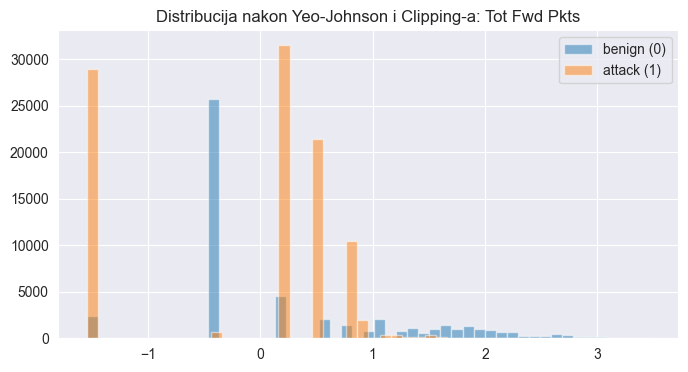

In [429]:
plt.figure(figsize=(8,4))
plt.hist(X_train_pt.loc[y_train==0, 'Tot Fwd Pkts'], bins=50, alpha=0.5, label='benign (0)')
plt.hist(X_train_pt.loc[y_train==1, 'Tot Fwd Pkts'], bins=50, alpha=0.5, label='attack (1)')
plt.legend()
plt.title('Distribucija nakon Yeo-Johnson i Clipping-a: Tot Fwd Pkts')
plt.show()

## 2. Model Training

In [430]:
def build_model(input_dim, hidden_layers=[64, 32], dropout=0.2, lr=0.001):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [431]:
input_dim = X_train_pt.shape[1]
baseline_model = build_model(input_dim)
baseline_model.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_123 (Dense)               │ (None, 64)             │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,745 (30.25 KB)

 Trainable params: 7,745 (30.25 KB)

 Non-trainable params: 0 (0.00 B)

In [432]:
architectures = {
    'small':        {'hidden_layers': [32, 16], 'dropout': 0.1, 'lr': 0.001},
    'medium':       {'hidden_layers': [64, 32], 'dropout': 0.2, 'lr': 0.001},
    'large':        {'hidden_layers': [128, 64, 32], 'dropout': 0.2, 'lr': 0.001},
    'wide':         {'hidden_layers': [256, 128], 'dropout': 0.3, 'lr': 0.001},
    'original_like':{'hidden_layers': [16, 256, 128], 'dropout': 0.1, 'lr': 0.0001},
    'xtra-large':   {'hidden_layers': [256, 256, 256], 'dropout': 0.05, 'lr': 0.0001},
}

In [433]:
results = {}

for name, params in architectures.items():
    print(f"\n--- Training: {name} ---")
    model = build_model(input_dim, **params)

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        X_train_pt, y_train,
        epochs=15,
        batch_size=64,
        validation_data=(X_test_pt, y_test),
        callbacks=[early_stop],
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    n_epochs_ran = len(history.history['loss'])

    results[name] = {
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'epochs_ran': n_epochs_ran,
        'n_params': model.count_params()
    }
    print(f"{name}: val_acc={val_acc:.4f}, val_loss={val_loss:.4f}, epochs={n_epochs_ran}")


--- Training: small ---
small: val_acc=0.9998, val_loss=0.0015, epochs=9

--- Training: medium ---
medium: val_acc=0.9997, val_loss=0.0014, epochs=9

--- Training: large ---
large: val_acc=0.9997, val_loss=0.0016, epochs=10

--- Training: wide ---
wide: val_acc=0.9997, val_loss=0.0015, epochs=11

--- Training: original_like ---
original_like: val_acc=0.9996, val_loss=0.0021, epochs=15

--- Training: xtra-large ---
xtra-large: val_acc=0.9998, val_loss=0.0013, epochs=7


In [434]:
model = build_model(input_dim=X_train_pt.shape[1], hidden_layers=[32, 16], dropout=0.1, lr=0.001)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_pt, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test_pt, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 359us/step - accuracy: 0.9923 - loss: 0.0251 - val_accuracy: 0.9994 - val_loss: 0.0032
Epoch 2/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 346us/step - accuracy: 0.9993 - loss: 0.0029 - val_accuracy: 0.9995 - val_loss: 0.0022
Epoch 3/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 377us/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.9995 - val_loss: 0.0024
Epoch 4/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 365us/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9996 - val_loss: 0.0028
Epoch 5/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 362us/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9997 - val_loss: 0.0025
Epoch 6/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 364us/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0016
Epoch 7/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 362us/step - accuracy: 0.9996 - loss: 0.0011 - val_accuracy: 0.9997 - val_loss: 0.0017
Epoch 8/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 366us/step - accuracy: 0.9998 -

### Class Weights

In [435]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{np.int64(0): np.float64(1.4416134434145962), np.int64(1): np.float64(0.7655017318926743)}


In [436]:
model_weighted = build_model(input_dim=X_train_pt.shape[1], hidden_layers=[32, 16], dropout=0.1, lr=0.001)

early_stop_w = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_weighted = model_weighted.fit(
    X_train_pt, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_test_pt, y_test),
    callbacks=[early_stop_w],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 376us/step - accuracy: 0.9888 - loss: 0.0301 - val_accuracy: 0.9994 - val_loss: 0.0037
Epoch 2/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 345us/step - accuracy: 0.9991 - loss: 0.0033 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 3/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 341us/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 0.9997 - val_loss: 0.0021
Epoch 4/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 340us/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9997 - val_loss: 0.0015
Epoch 5/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9997 - val_loss: 0.0019
Epoch 6/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 343us/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9996 - val_loss: 0.0018
Epoch 7/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0014
Epoch 8/50
2314/2314 ━━━━━━━━━━━━━━━━━━━━ 1s 343us/step - accuracy: 0.9997 -

In [437]:
y_pred_base = (model.predict(X_test_pt) > 0.5).astype("int32")
y_pred_weighted = (model_weighted.predict(X_test_pt) > 0.5).astype("int32")

1157/1157 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step
1157/1157 ━━━━━━━━━━━━━━━━━━━━ 0s 157us/step


In [438]:
print("=== BEZ class_weight ===")
print(classification_report(y_test, y_pred_base))

print("\n=== SA class_weight ===")
print(classification_report(y_test, y_pred_weighted))

=== BEZ class_weight ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12839
           1       1.00      1.00      1.00     24179

    accuracy                           1.00     37018
   macro avg       1.00      1.00      1.00     37018
weighted avg       1.00      1.00      1.00     37018


=== SA class_weight ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12839
           1       1.00      1.00      1.00     24179

    accuracy                           1.00     37018
   macro avg       1.00      1.00      1.00     37018
weighted avg       1.00      1.00      1.00     37018



## 3. Model Evaluation on Test Data

In [439]:
y_pred = (model.predict(X_test_pt) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

1157/1157 ━━━━━━━━━━━━━━━━━━━━ 0s 147us/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12839
           1       1.00      1.00      1.00     24179

    accuracy                           1.00     37018
   macro avg       1.00      1.00      1.00     37018
weighted avg       1.00      1.00      1.00     37018



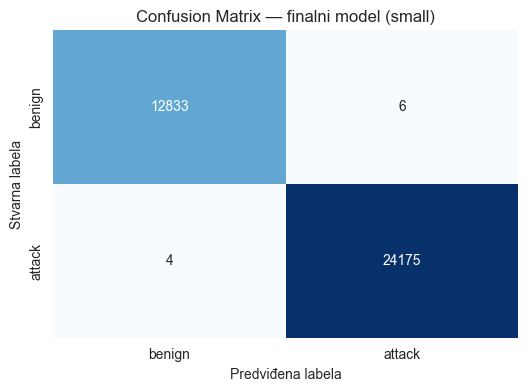

In [440]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sb.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['benign', 'attack'], yticklabels=['benign', 'attack'])
plt.title("Confusion Matrix — finalni model (small)")
plt.xlabel("Predviđena labela")
plt.ylabel("Stvarna labela")
plt.show()

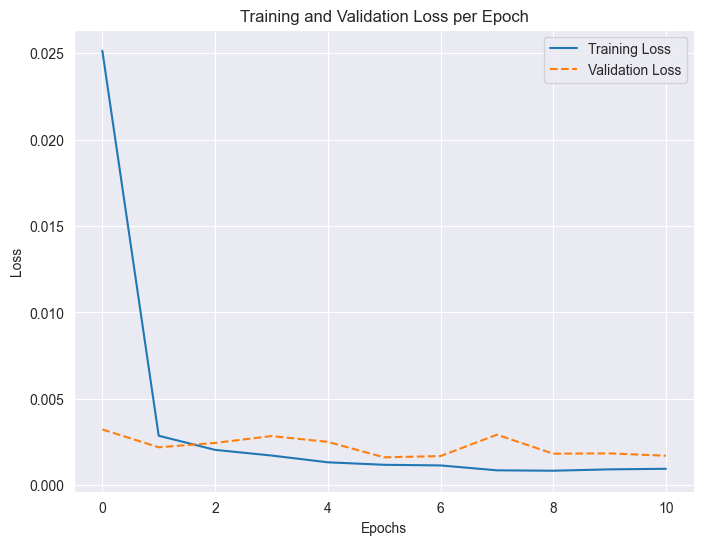

In [441]:
# Extract loss and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plotting training and validation loss
plt.figure(figsize=(8,6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='--')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

1157/1157 ━━━━━━━━━━━━━━━━━━━━ 0s 149us/step


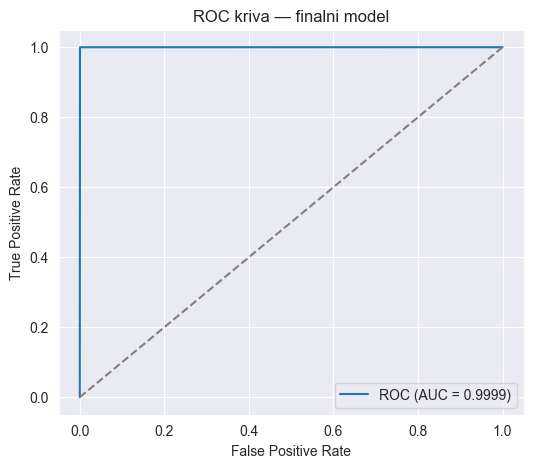

In [442]:
y_prob = model.predict(X_test_pt)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC kriva — finalni model')
plt.legend()
plt.show()

In [443]:
# Regenerate the classification report with 'output_dict=True'
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision    recall  f1-score      support
0              0.999688  0.999533  0.999611  12839.00000
1              0.999752  0.999835  0.999793  24179.00000
accuracy       0.999730  0.999730  0.999730      0.99973
macro avg      0.999720  0.999684  0.999702  37018.00000
weighted avg   0.999730  0.999730  0.999730  37018.00000


## 4. Model Evaluation on Unseen Data

In [449]:
# path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

eval_df = pd.read_csv(Path().cwd() / 'data' / 'friday_ddos.csv')
eval_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [450]:
print(df.columns)
print(eval_df.columns)

Index(['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts',
       'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min',
       'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s',
       'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Bwd PSH Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
       'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts',
       'Sub

In [451]:
rename_dict = {
    "Destination Port": "Dst Port",
    "Flow Duration": "Flow Duration",
    "Total Fwd Packets": "Tot Fwd Pkts",
    "Total Backward Packets": "Tot Bwd Pkts",
    "Total Length of Fwd Packets": "TotLen Fwd Pkts",
    "Total Length of Bwd Packets": "TotLen Bwd Pkts",
    "Fwd Packet Length Max": "Fwd Pkt Len Max",
    "Fwd Packet Length Min": "Fwd Pkt Len Min",
    "Fwd Packet Length Mean": "Fwd Pkt Len Mean",
    "Fwd Packet Length Std": "Fwd Pkt Len Std",
    "Bwd Packet Length Max": "Bwd Pkt Len Max",
    "Bwd Packet Length Min": "Bwd Pkt Len Min",
    "Bwd Packet Length Mean": "Bwd Pkt Len Mean",
    "Bwd Packet Length Std": "Bwd Pkt Len Std",
    "Flow Bytes/s": "Flow Byts/s",
    "Flow Packets/s": "Flow Pkts/s",
    "Flow IAT Mean": "Flow IAT Mean",
    "Flow IAT Std": "Flow IAT Std",
    "Flow IAT Max": "Flow IAT Max",
    "Flow IAT Min": "Flow IAT Min",
    "Fwd IAT Total": "Fwd IAT Tot",
    "Fwd IAT Mean": "Fwd IAT Mean",
    "Fwd IAT Std": "Fwd IAT Std",
    "Fwd IAT Max": "Fwd IAT Max",
    "Fwd IAT Min": "Fwd IAT Min",
    "Bwd IAT Total": "Bwd IAT Tot",
    "Bwd IAT Mean": "Bwd IAT Mean",
    "Bwd IAT Std": "Bwd IAT Std",
    "Bwd IAT Max": "Bwd IAT Max",
    "Bwd IAT Min": "Bwd IAT Min",
    "Fwd PSH Flags": "Fwd PSH Flags",
    "Bwd PSH Flags": "Bwd PSH Flags",
    "Fwd URG Flags": "Fwd URG Flags",
    "Bwd URG Flags": "Bwd URG Flags",
    "Fwd Header Length": "Fwd Header Len",
    "Bwd Header Length": "Bwd Header Len",
    "Fwd Packets/s": "Fwd Pkts/s",
    "Bwd Packets/s": "Bwd Pkts/s",
    "Min Packet Length": "Pkt Len Min",
    "Max Packet Length": "Pkt Len Max",
    "Packet Length Mean": "Pkt Len Mean",
    "Packet Length Std": "Pkt Len Std",
    "Packet Length Variance": "Pkt Len Var",
    "FIN Flag Count": "FIN Flag Cnt",
    "SYN Flag Count": "SYN Flag Cnt",
    "RST Flag Count": "RST Flag Cnt",
    "PSH Flag Count": "PSH Flag Cnt",
    "ACK Flag Count": "ACK Flag Cnt",
    "URG Flag Count": "URG Flag Cnt",
    "CWE Flag Count": "CWE Flag Count",
    "ECE Flag Count": "ECE Flag Cnt",
    "Down/Up Ratio": "Down/Up Ratio",
    "Average Packet Size": "Pkt Size Avg",
    "Avg Fwd Segment Size": "Fwd Seg Size Avg",
    "Avg Bwd Segment Size": "Bwd Seg Size Avg",
    "Fwd Header Length.1": "toDrop",  # CICIDS duplikat, mapira se na isti naziv ili ga kasnije dropuješ
    "Fwd Avg Bytes/Bulk": "Fwd Byts/b Avg",
    "Fwd Avg Packets/Bulk": "Fwd Pkts/b Avg",
    "Fwd Avg Bulk Rate": "Fwd Blk Rate Avg",
    "Bwd Avg Bytes/Bulk": "Bwd Byts/b Avg",
    "Bwd Avg Packets/Bulk": "Bwd Pkts/b Avg",
    "Bwd Avg Bulk Rate": "Bwd Blk Rate Avg",
    "Subflow Fwd Packets": "Subflow Fwd Pkts",
    "Subflow Fwd Bytes": "Subflow Fwd Byts",
    "Subflow Bwd Packets": "Subflow Bwd Pkts",
    "Subflow Bwd Bytes": "Subflow Bwd Byts",
    "Init_Win_bytes_forward": "Init Fwd Win Byts",
    "Init_Win_bytes_backward": "Init Bwd Win Byts",
    "act_data_pkt_fwd": "Fwd Act Data Pkts",
    "min_seg_size_forward": "Fwd Seg Size Min",
    "Active Mean": "Active Mean",
    "Active Std": "Active Std",
    "Active Max": "Active Max",
    "Active Min": "Active Min",
    "Idle Mean": "Idle Mean",
    "Idle Std": "Idle Std",
    "Idle Max": "Idle Max",
    "Idle Min": "Idle Min",
    "Label": "target",
}

In [452]:
eval_df.columns = eval_df.columns.str.strip()

In [453]:
eval_df = eval_df.rename(columns=rename_dict)

In [454]:
eval_df.drop(columns=["toDrop"], inplace=True)

In [455]:
eval_df.shape

(225745, 78)

In [456]:
#eval_df.drop(columns=['Timestamp'], inplace=True)
eval_df.drop(columns=constant_cols, inplace=True)

In [457]:
eval_df['Dst Port Cat'] = eval_df['Dst Port'].apply(bucket_port)

eval_df = pd.get_dummies(eval_df, columns=['Dst Port Cat'], prefix=['dst_port'])

eval_df = eval_df.drop(columns=['Dst Port'])
eval_df.shape

(225745, 73)

In [458]:
# 1. Pronađi sve kolone koje počinju sa 'dst_port_'
dst_cols = [col for col in df.columns if col.startswith("src_port_") or col.startswith("protocol_")]

# 2. Napravi rečnik gde menjaš prefiks u 'src_' i postavljaš vrednost na 0
new_cols = {col: 0 for col in dst_cols}

# 3. Dodaj sve kolone odjednom u DataFrame
eval_df = eval_df.assign(**new_cols)
eval_df.shape

(225745, 85)

In [459]:
eval_df["dst_port_llmnr"] = eval_df["dst_port_https"].apply(lambda x: 0)
eval_df["dst_port_mysql"] = eval_df["dst_port_https"].apply(lambda x: 0)
eval_df["dst_port_ssdp"] = eval_df["dst_port_https"].apply(lambda x: 0)

In [460]:
eval_df['target'].value_counts()

target
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

In [461]:
eval_df["target"] = eval_df["target"].apply(lambda x: 1 if x == "DDoS" else 0)
eval_df['target'].value_counts()

target
1    128027
0     97718
Name: count, dtype: int64

In [462]:
eval_df.replace([np.inf, -np.inf], np.nan, inplace=True)
eval_df.dropna(inplace=True)
eval_df.reset_index(drop=True, inplace=True)
eval_df.shape

(225711, 88)

In [463]:
X_eval = eval_df.drop(columns=['target'])
y_eval = eval_df['target']

In [464]:
X_eval_pt = X_eval.copy()
X_eval_pt[transform_cols] = pt.transform(X_eval[transform_cols])

In [465]:
X_eval_pt[transform_cols] = X_eval_pt[transform_cols].clip(-CLIP_VAL, CLIP_VAL)

In [466]:
y_eval_pred = (model.predict(X_eval_pt) > 0.5).astype("int32")

7054/7054 ━━━━━━━━━━━━━━━━━━━━ 1s 154us/step


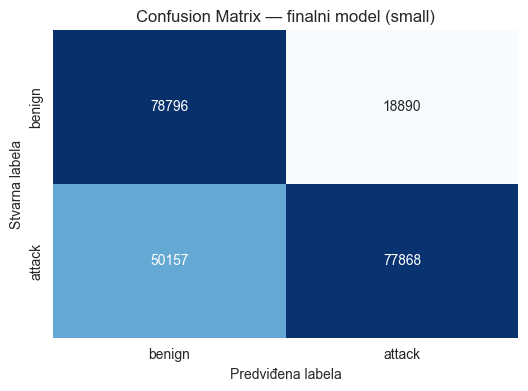

In [467]:
conf_matrix = confusion_matrix(y_eval, y_eval_pred)

plt.figure(figsize=(6,4))
sb.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['benign', 'attack'], yticklabels=['benign', 'attack'])
plt.title("Confusion Matrix — finalni model (small)")
plt.xlabel("Predviđena labela")
plt.ylabel("Stvarna labela")
plt.show()

In [468]:
print(classification_report(y_eval, y_eval_pred))

              precision    recall  f1-score   support

           0       0.61      0.81      0.70     97686
           1       0.80      0.61      0.69    128025

    accuracy                           0.69    225711
   macro avg       0.71      0.71      0.69    225711
weighted avg       0.72      0.69      0.69    225711

